In [ ]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import math as mt
import lightgbm as lgb
import shap
import json
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, StratifiedKFold, TimeSeriesSplit
from catboost import CatBoostClassifier, Pool
from optuna.samplers import TPESampler

## 1. Загрузка датасета

Загрузка синтетически расширенного датасета `uplift-dataset.csv`. Датасет содержит признаки клиентов Home Credit, дополненные uplift-переменными.


In [2]:
import os

DATA_PATH = "data/processed"  # обработанные данные
MODELS_PATH = "models/cboost"  # сохранение модели
FEATURES_PATH = "features"     # важность признаков

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(FEATURES_PATH, exist_ok=True)

In [3]:
RANDOM_SEED = 91

In [4]:
np.random.seed(RANDOM_SEED)

In [5]:
df = pd.read_csv(DATA_PATH + "/uplift-dataset.csv")

print("Dataset shape:", df.shape)

Dataset shape: (307511, 161)


## 2. Первичный осмотр данных

Проверка формы датасета, типов данных и доли пропущенных значений. Целевая переменная — `TARGET` (бинарный индикатор дефолта). Доля дефолтов в выборке составляет ~8%, что создаёт дисбаланс классов.


In [6]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SK_DPD_MAX_CC,BASE_PD,CONTACT_PROPENSITY,RISK_SEGMENT,CONTACT_HISTORY,PREFERRED_CHANNEL,INTERACTION_SCORE,DELAY_FLAG,COMMUNICATION,TRUE_UPLIFT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,0.950968,0.609805,high_risk,9,sms,0.450668,1,operator_call,0.028513
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,0.608977,0.456933,high_risk,0,operator_call,0.341462,1,control,-0.005344
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,0.227401,0.148340,low_risk,0,sms,0.483622,0,control,0.003340
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.359173,0.253956,low_risk,2,robot_call,0.461974,0,control,-0.021130
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,0.629868,0.420203,high_risk,2,robot_call,0.437186,0,control,-0.004420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,NaN,0.661227,0.430674,high_risk,3,operator_call,0.469229,1,control,-0.001041
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,NaN,0.671782,0.425683,high_risk,2,sms,0.467030,0,operator_call,-0.068337
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,NaN,0.423995,0.311099,medium_risk,0,sms,0.416992,0,control,-0.010546
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,NaN,0.376648,0.259927,low_risk,1,sms,0.455039,1,control,-0.012077


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 161 entries, SK_ID_CURR to TRUE_UPLIFT
dtypes: float64(99), int64(43), object(19)
memory usage: 377.7+ MB


In [8]:
df['TARGET'].value_counts(normalize=True).round(4) * 100

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

In [9]:
dt_cols = df.select_dtypes(include=['datetime64']).columns.to_list()
object_cols = df.select_dtypes(include=['object']).columns.to_list()
num_cols = df.select_dtypes(include=['number']).columns.to_list()
flg_cols = [col for col in df.columns if col.startswith("FLAG_")] + [
    "LIVE_CITY_NOT_WORK_CITY",
    "LIVE_REGION_NOT_WORK_REGION",
    "REG_CITY_NOT_LIVE_CITY",
    "REG_CITY_NOT_WORK_CITY",
    "REG_REGION_NOT_LIVE_REGION",
    "REG_REGION_NOT_WORK_REGION"
]


target = "TARGET"

uplift_cols = [
  "BASE_PD",
  "CONTACT_PROPENSITY",
  "COMMUNICATION",
  "RISK_SEGMENT",
  "CONTACT_HISTORY",
  "PREFERRED_CHANNEL",
  "INTERACTION_SCORE",
  "DELAY_FLAG",
  "TRUE_UPLIFT",
]


num_cols = sorted(list(set(num_cols) - set(flg_cols)))

num_cols.remove('TARGET')

In [10]:
dt_cols

[]

In [11]:
object_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE',
 'RISK_SEGMENT',
 'PREFERRED_CHANNEL',
 'COMMUNICATION']

In [12]:
num_cols

['AMT_ANNUITY',
 'AMT_APPLICATION_MAX',
 'AMT_APPLICATION_MEAN',
 'AMT_BALANCE_MAX',
 'AMT_BALANCE_MEAN',
 'AMT_CREDIT',
 'AMT_CREDIT_LIMIT_ACTUAL_MEAN',
 'AMT_CREDIT_MAX',
 'AMT_CREDIT_MEAN',
 'AMT_CREDIT_SUM_DEBT_MEAN',
 'AMT_CREDIT_SUM_DEBT_SUM',
 'AMT_CREDIT_SUM_MEAN',
 'AMT_CREDIT_SUM_OVERDUE_SUM',
 'AMT_CREDIT_SUM_SUM',
 'AMT_DRAWINGS_CURRENT_MEAN',
 'AMT_GOODS_PRICE',
 'AMT_INCOME_TOTAL',
 'AMT_INSTALMENT_MEAN',
 'AMT_PAYMENT_MEAN',
 'AMT_PAYMENT_SUM',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_YEAR',
 'APARTMENTS_AVG',
 'APARTMENTS_MEDI',
 'APARTMENTS_MODE',
 'BASEMENTAREA_AVG',
 'BASEMENTAREA_MEDI',
 'BASEMENTAREA_MODE',
 'BASE_PD',
 'CNT_CHILDREN',
 'CNT_FAM_MEMBERS',
 'CNT_INSTALMENT_FUTURE_MEAN',
 'CNT_INSTALMENT_MEAN',
 'CNT_PAYMENT_MEAN',
 'COMMONAREA_AVG',
 'COMMONAREA_MEDI',
 'COMMONAREA_MODE',
 'CONTACT_HISTORY',
 'CONTACT_PROPENSITY',
 '

In [13]:
flg_cols

['FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21',
 'LIVE_CITY_NOT_WORK_CITY',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION']

## 3. Генерация производных признаков

На основе исходных переменных формируются новые информативные признаки:

- `AGE_YEARS` = `|DAYS_BIRTH| / 365` — возраст клиента в годах
- `EMPLOYMENT_RATIO` = `DAYS_EMPLOYED / DAYS_BIRTH` — доля занятого времени
- `CREDIT_HISTORY_LENGTH` — длина кредитной истории
- `ANNUITY_TO_INCOME` = `AMT_ANNUITY / AMT_INCOME_TOTAL` — долговая нагрузка


In [14]:
# Возраст в годах
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365

# Стаж работы
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365

# Доля стажа от возраста
df["EMPLOYMENT_RATIO"] = df["EMPLOYMENT_YEARS"] / df["AGE_YEARS"]

# Давность кредитной истории
df["CREDIT_HISTORY_LENGTH"] = (
    df["DAYS_CREDIT_MAX"] - df["DAYS_CREDIT_MIN"]
)

# Активность по кредитке
df["MONTHS_BALANCE_RANGE"] = (
    df["MONTHS_BALANCE_MIN"] - df["MONTHS_BALANCE_MEAN"]
)

## 4. Предобработка датасета

Обработка пропущенных значений, приведение типов и отбор признаков по доле пропусков (`MAX_MISSING_RATIO = 0.8`). Переменные с более чем 80% пропусков исключаются из рассмотрения.


In [15]:
def transform_to_standart_types(df: pd.DataFrame) -> pd.DataFrame:
    """
    Преобразует все колонки к стандартным типам данных

    Args:
        df (pd.DataFrame): Датафрейм с данными для обучения модели
    Returns:
        df (pd.DataFrame): Датафрейм с данными для обучения модели с преобразованными колонками
    """

    cat_features = df.select_dtypes(object).columns.to_list()

    df[cat_features] = df[cat_features].replace(np.nan, 'NaN')

    for feature in cat_features:
        df[feature] = df[feature].astype(str)

    for col in df.select_dtypes(include=[np.int64]).columns.to_list():
        df[col] = df[col].astype(np.float64)

    return df

def fillna_categorical(df: pd.DataFrame) -> pd.DataFrame:
    """
    Заполняет пропуски в категориальных переменных

    Args:
        df (pd.DataFrame): Датафрейм с данными для обучения модели
    Returns:
        df (pd.DataFrame): Датафрейм с данными для обучения модели с преобразованными колонками
    """

    cat_features = df.select_dtypes(object).columns.to_list()

    df[cat_features] = df[cat_features].fillna('NaN')
    df[cat_features] = df[cat_features].replace([np.nan, 'None', 'N/A'], 'NaN')

    return df

def drop_unnecessary_columns(df: pd.DataFrame, max_missing_ratio=0.8) -> pd.DataFrame:
    """
    Удаляет ненужные, константные колонки, а также колонки с большой долей пропусков

    Args:
        df (pd.DataFrame): Датафрейм с данными для обучения модели
        max_missing_ratio (float): Порог отсечения переменных с большой долей пропусков
    Returns:
        df (pd.DataFrame): Датафрейм с данными для обучения модели c удаленными ненужными колонками
    """

    unnecessary_columns = ['SK_ID_CURR']

    for col in unnecessary_columns:
        if col in df.columns:
            df = df.drop(col, axis=1)

    missing_ratio = df.isna().mean()
    high_missing_ratio = missing_ratio[missing_ratio > max_missing_ratio].index.to_list()
    df = df.drop(high_missing_ratio, axis=1)

    constant_columns = df.nunique(dropna=False).to_frame()
    constant_columns = constant_columns[constant_columns[0] < 2].index.to_list()
    df = df.drop(constant_columns, axis=1)

    return df

In [16]:
X = df.drop(columns=target).copy()
y = df[target].copy()

In [17]:
X = fillna_categorical(X)
X = transform_to_standart_types(X)

In [18]:
X = drop_unnecessary_columns(X)

In [19]:
filtred_cols = X.columns.tolist()

> **Примечание.** Для построения модели используются числовые и категориальные признаки после предобработки. Uplift-переменные (`COMMUNICATION`, `TRUE_UPLIFT`, `BASE_PD` и др.) в обучение модели не включаются — они используются только для верификации и сравнения.


In [20]:
corr = df[num_cols].corrwith(df["TARGET"]).abs().sort_values(ascending=False).round(2)

In [21]:
corr

BASE_PD                       0.20
CONTACT_PROPENSITY            0.18
EXT_SOURCE_3                  0.18
EXT_SOURCE_2                  0.16
EXT_SOURCE_1                  0.16
                              ... 
AMT_REQ_CREDIT_BUREAU_QRT     0.00
NONLIVINGAPARTMENTS_MODE      0.00
AMT_REQ_CREDIT_BUREAU_HOUR    0.00
AMT_REQ_CREDIT_BUREAU_WEEK    0.00
AMT_CREDIT_SUM_DEBT_MEAN      0.00
Length: 109, dtype: float64

С помощью корреляции с таргетом произвели проверку наличия признаков с "утечкой" данных

In [22]:
print(f'Из исходных {len(df.columns.tolist())} переменных для построения будем рассматривать {len(filtred_cols)}')

Из исходных 166 переменных для построения будем рассматривать 164


## 5. Разделение данных на выборки

Данные разделяются на три непересекающихся выборки:

- **OOT (out-of-time)**: первые 20% наблюдений — выборка для итоговой оценки
- **Train**: 60% от оставшихся — обучающая выборка
- **Test**: 40% от оставшихся — валидационная выборка

Разбивка стратифицирована по целевой переменной. `random_state=RANDOM_SEED` обеспечивает воспроизводимость.


In [23]:
data = X.copy()
data[target] = y.copy()

In [24]:
train_test  = data[mt.ceil(len(data)*0.2):].copy(deep=True)
oot  = data[:mt.ceil(len(data)*0.2)].copy(deep=True)

X_train, X_test, y_train, y_test = train_test_split(
    train_test.drop(columns=target), train_test[target],
    test_size=0.25, stratify=train_test[target],
    random_state=RANDOM_SEED)

X_oot, y_oot = oot.drop(columns=target), oot[target]

train = X_train.copy()
train[target] = y_train

test = X_test.copy()
test[target] = y_test

In [25]:
print(f'Доля наблюдений на train: {len(X_train)/len(data) * 100:.2f}%')
print(f'Доля наблюдений на test: {len(X_test)/len(data) * 100:.2f}%')
print(f'Доля наблюдений на oot: {len(X_oot)/len(data) * 100:.2f}%')

Доля наблюдений на train: 60.00%
Доля наблюдений на test: 20.00%
Доля наблюдений на oot: 20.00%


In [26]:
print(f'Общее количество наблюдений: {len(data)}')
print(f'Количество наблюдений на train: {len(X_train)}')
print(f'Количество наблюдений на test: {len(X_test)}')
print(f'Количество наблюдений на oot: {len(X_oot)}')

Общее количество наблюдений: 307511
Количество наблюдений на train: 184506
Количество наблюдений на test: 61502
Количество наблюдений на oot: 61503


In [27]:
print(f'Общий BR на всех данных: {round(data[target].mean() * 100, 4)}%')
print(f'BR на train: {round(y_train.mean() * 100, 4)}%')
print(f'BR на test: {round(y_test.mean() * 100, 4)}%')
print(f'BR на oot: {round(y_oot.mean() * 100, 4)}%')

Общий BR на всех данных: 8.0729%
BR на train: 8.0881%
BR на test: 8.0875%
BR на oot: 8.0126%


---

## 6. Отбор признаков

Отбор признаков выполняется в три этапа:

1. **Feature Importance** — оценка значимости всех переменных через PredictionValuesChange, SHAP и Solo Gini
2. **Фильтрация по корреляции** — удаление мультиколлинеарных признаков (порог 0.8)
3. **Forward Selection** — определение оптимального числа признаков через кросс-валидацию


In [28]:
features = data.columns.tolist()
features.remove('TARGET')

In [29]:
features = [col for col in features if col not in uplift_cols]

### 6.1 Оценка значимости признаков

Для каждого признака вычисляется важность тремя методами:

- **PredictionValuesChange** — встроенная метрика CatBoost, отражающая вклад признака в снижение потерь
- **SHAP values** — среднее абсолютное SHAP-значение, интерпретируемое как вклад в предсказание
- **Solo Gini** — Gini-коэффициент модели, обученной только на одном признаке

Признаки, не прошедшие минимальный порог ни по одной метрике, исключаются.


In [ ]:
def get_catboost_gini(features, target, train, test, verb=100, trees=1000):
    """Обучение модели CatBoostClassifier и расчет Gini на выборках train, test"""

    cat_features = train[features].select_dtypes(['category', 'object']).columns.to_list()

    model = CatBoostClassifier(n_estimators=trees,
                               eval_metric='NormalizedGini',
                               cat_features = cat_features,
                               verbose=verb,
                               random_state=RANDOM_SEED)

    model.fit(train[features], train[target])

    gini_train = roc_auc_score(train[target], model.predict_proba(train[features])[:,1] ) * 2 - 1
    gini_test =  roc_auc_score(test[target],  model.predict_proba(test[features])[:,1] ) * 2 - 1
    print(f'Gini train: {gini_train}, Gini test: {gini_test}')

    return model

In [31]:
model = get_catboost_gini(features, target, train, test, verb=100, trees=1000)

Learning rate set to 0.095614
0:	total: 268ms	remaining: 4m 27s
100:	total: 11.5s	remaining: 1m 42s
200:	total: 22.4s	remaining: 1m 29s
300:	total: 33.1s	remaining: 1m 16s
400:	total: 44s	remaining: 1m 5s
500:	total: 54.8s	remaining: 54.5s
600:	total: 1m 5s	remaining: 43.5s
700:	total: 1m 16s	remaining: 32.5s
800:	total: 1m 26s	remaining: 21.5s
900:	total: 1m 36s	remaining: 10.6s
999:	total: 1m 47s	remaining: 0us
Gini train: 0.7189898911363206, Gini test: 0.5499456998071262


In [32]:
fi = pd.DataFrame({'Name': features, 'fi': model.feature_importances_})

In [33]:
fi = fi[fi['fi'] != 0].sort_values('fi', ascending=False)

In [34]:
fi

,Name,fi
40,EXT_SOURCE_2,8.639511
41,EXT_SOURCE_3,7.658418
39,EXT_SOURCE_1,3.845804
6,AMT_CREDIT,3.029094
8,AMT_GOODS_PRICE,2.592015
...,...,...
47,ELEVATORS_AVG,0.009395
109,FLAG_DOCUMENT_17,0.006658
111,FLAG_DOCUMENT_19,0.004881
94,FLAG_DOCUMENT_2,0.004137


### 6.2 Фильтрация по корреляции

Из списка значимых признаков удаляются мультиколлинеарные пары. Для каждой пары с корреляцией Пирсона > 0.8 сохраняется признак с более высокой важностью. Это снижает мультиколлинеарность и уменьшает размерность признакового пространства.


In [35]:
def get_iv(df, feature, y, bins=None):
    """
    Возвращает значение IV
    Args:
    df (pd.DataFrame): Датафрейм, на котором будет подсчитываться IV
    feature (str): признак для подсчета IV
    y (pd.Series | np.ndarray): Истинные значения
    bins (int | None): число бинов для разбиения
    Returns:
    Значение IV
    """
    lst = []
    target = 'y'
    df[target] = y
    if bins:
        df[feature] = pd.cut(df[feature], bins=bins)

    unique_values = df[feature].unique()
    for val in unique_values:
        lst.append([feature,                                                        # Feature name
                    val,                                                            # Value of a feature (unique)
                    df[(df[feature] == val) & (df[target] == 0)].count()[feature],  # Good (Fraud == 0)
                    df[(df[feature] == val) & (df[target] == 1)].count()[feature]   # Bad  (Fraud == 1)
                    ])

    data = pd.DataFrame(lst, columns=['Variable', 'Value', 'Good', 'Bad'])

    total_bad = df[df[target] == 1].count()[feature]
    total_good = df.shape[0] - total_bad

    data['Distribution Good'] = data['Good']/ total_good
    data['Distribution Bad'] = data['Bad'] / total_bad
    data['WoE'] = np.log(data['Distribution Good'] / data['Distribution Bad'])

    data = data.replace({'WoE': {np.inf: 0, -np.inf: 0}})

    data['IV'] = data['WoE'] * (data['Distribution Good'] - data['Distribution Bad'])

    data = data.sort_values(by=['Variable', 'Value'], ascending=[True, True])
    data.index = range(len(data.index))

    iv = data['IV'].sum()

    return iv

In [36]:
cat_features = train[features].select_dtypes(['category', 'object']).columns.tolist()
num_features = [feature for feature in features if feature not in cat_features]

In [37]:
corr_matrix = X_train[num_features].corr().abs()
to_drop = set()

thresold = 0.8

checked_cols = []

for i in tqdm(range(len(num_features))):
    for j in range(i + 1, len(num_features)):
        col1 = num_features[i]
        col2 = num_features[j]
        if col2 != col1 and corr_matrix[col1][col2] >= thresold:
            if fi[fi['Name']==col1]['fi'].values < fi[fi['Name']==col2]['fi'].values:
                to_drop.add(col1)
            else:
                to_drop.add(col2)

100%|██████████| 139/139 [00:00<00:00, 2853.65it/s]


In [38]:
print(f'Было удалено {len(to_drop)} переменных')

Было удалено 54 переменных


In [39]:
filtred_cols = [col for col in features if col not in to_drop]

In [40]:
print(f'После удаления осталось {len(filtred_cols)} переменных')

После удаления осталось 101 переменных


In [41]:
# Сохраним отфильтрованные переменные
fi[fi['Name'].isin(filtred_cols)].to_excel(os.path.join(FEATURES_PATH, "filtred_features.xlsx"), index=False)

### 6.3 Оценка Gini и SHAP по отфильтрованному списку

После фильтрации по корреляции для оставшихся признаков повторно вычисляются Solo Gini и SHAP-значения. Это позволяет уточнить ранжирование признаков с учётом их независимого вклада в предсказательную силу модели.


In [42]:
features = filtred_cols

In [43]:
def get_important_features(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """
    Возвращает фичи и их важность по: SHAP, PredictionValuesChange, Gini

    Args:
        df (pd.DataFrame): Датафрейм с данными для обучения модели
        target (str): название таргета на котором обучается модель
    Returns:
        feature_selection_list (pd.DataFrame): Датафрейм с переменными и их значимостью по PredictionValuesChange
        features_shap (pd.DataFrame): Датафрейм с переменными и их значимостью по SHAP
        features_gini (pd.DataFrame): Датафрейм с переменными и их значимостью по Gini
    """

    X = df.drop(target, axis=1)
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    cat_features = df.select_dtypes(['category', 'object']).columns.to_list()

    feature_selection_model = CatBoostClassifier(
        eval_metric='NormalizedGini',
        iterations=100,
        random_seed=RANDOM_SEED,
        auto_class_weights='Balanced'
    )

    feature_selection_model.fit(X_train, y_train, eval_set=(X_test, y_test), cat_features=cat_features, plot=False,
                                verbose=0)

    gain = feature_selection_model.get_feature_importance(type='PredictionValuesChange')
    total = sum(gain)
    feature_selection_list = pd.DataFrame({'Name': list(X_train.columns), 'Value': gain / total})
    feature_selection_list = feature_selection_list.sort_values('Value', ascending=False)
    feature_selection_list.index = range(1, feature_selection_list.shape[0] + 1)

    explainer = shap.TreeExplainer(feature_selection_model)
    shap_values = explainer.shap_values(Pool(X_train, cat_features=cat_features))

    features_shap = pd.DataFrame({'Name': X_train.columns, 'Value': np.mean(abs(shap_values), axis=0)})
    features_shap = features_shap.sort_values('Value', ascending=False)
    features_shap.index = range(1, features_shap.shape[0] + 1)

    gini = {}

    for feature in tqdm(X_train.columns):
        try:
            model = CatBoostClassifier(eval_metric='NormalizedGini', iterations=10, random_seed=RANDOM_SEED, verbose=0)

            is_categorical = feature in cat_features
            model.fit(X_train[[feature]], y_train, cat_features=[0] if is_categorical else None)
            y_pred_proba = model.predict_proba(X_test[[feature]])[:, 1]

            gini[feature] = round(2 * roc_auc_score(y_test, y_pred_proba) - 1, 3)
        except:
            continue

    features_gini = pd.DataFrame(list(gini.items()), columns=['Name', 'Value']).sort_values('Value', ascending=False)
    features_gini.index = range(1, features_gini.shape[0] + 1)

    return feature_selection_list, features_shap, features_gini

In [44]:
# Посчитаем для переменных SHAP, PredictionValuesChange, Gini
feature_selection_list, features_shap, features_gini = get_important_features(train[features + [target]], target)

100%|██████████| 101/101 [00:13<00:00,  7.50it/s]


In [45]:
features_gini = features_gini[features_gini['Value'] >= 0.05]

feature_selection_list = feature_selection_list[feature_selection_list['Value'] >= 0.005]

features_shap = features_shap[features_shap['Name'].isin(features_gini['Name'])]

features_shap = features_shap[features_shap['Name'].isin(feature_selection_list['Name'])]

In [46]:
features_shap.head()

,Name,Value
1,EXT_SOURCE_2,0.340035
2,EXT_SOURCE_3,0.336259
3,EXT_SOURCE_1,0.178543
4,AMT_PAYMENT_SUM,0.122209
5,AGE_YEARS,0.122199


In [47]:
len(features_shap)

37

### 6.4 Forward Selection

Итеративный метод отбора: признаки включаются в модель по одному в порядке убывания SHAP-важности. На каждом шаге оценивается Gini на кросс-валидации (3-fold KFold). Оптимальное число признаков определяется по минимуму разрыва train/test Gini при приемлемом уровне качества.


In [48]:
def get_features_short_list(df: pd.DataFrame, best_features_df: pd.DataFrame, num_features_step: int, target: str, params=None) -> pd.DataFrame:
    """
    Возвращает датафрейм с данными по тому, какое качество модели получается с разным кол-вом фичей

    Args:
        df (pd.DataFrame): Датафрейм с данными для обучения модели
        best_features_df (pd.DataFrame): Датафрейм с переменными и их значимостью
        num_features_step (int): длина шага между разными попытками обучения модели
        target (str): название таргета на котором обучается модель
        params (dict): словарь с параметрами для LGBM
    Returns:
        f (pd.DataFrame): Датафрейм с кол-вом переменных и их Gini
    """

    skf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

    i = 0
    f = pd.DataFrame(columns=['Number of features',
                              'gini_test',
                              'gini_train',
                              'difference',
                              ])

    cat_features = df.select_dtypes(['category', 'object']).columns.to_list()

    for feature in cat_features:
        df[feature] = df[feature].astype('category')

    X = df.drop(target, axis=1)
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    X_train = X_train.reset_index(drop=True)

    if params is None:
        params = {
            'learning_rate': [0.05],
            'metric': {'auc'},
            'boosting_type': 'gbdt',
            'objective': 'binary',
            'early_stopping_round': 7,
            'nthread': 2,
            'verbose': 0
        }

    k = num_features_step
    while k < len(best_features_df):

        column = list(best_features_df.loc[:k, 'Name'])

        w = []
        best_iter = []

        for train_index, val_index in skf.split(X_train, y_train):
            x_train_1, x_valid_1 = X_train.loc[train_index, column], X_train.loc[val_index, column]
            y_train_1, y_valid_1 = y_train.iloc[train_index], y_train.iloc[val_index]

            feature_name = x_train_1.columns.to_list()
            cat_features = x_train_1.select_dtypes([object, 'category']).columns.to_list()

            train_data = lgb.Dataset(x_train_1, label=y_train_1, categorical_feature=cat_features,
                                     feature_name=feature_name)
            val_data = lgb.Dataset(x_valid_1, label=y_valid_1, reference=train_data, categorical_feature=cat_features,
                                   feature_name=feature_name)
            gbm = lgb.train(params,
                            train_data,
                            valid_sets=[train_data, val_data],
                            valid_names=['train', 'val'],
                            num_boost_round=1000
                            )
            w.append([round(2 * gbm.best_score['train']['auc'] - 1, 2), round(2 * gbm.best_score['val']['auc'] - 1, 2)])

        res = list(np.mean(w, axis=0))

        gini_train = res[0]
        gini_test = res[1]
        f.loc[i, :] = k, gini_test, gini_train, gini_train - gini_test
        print(k, gini_test, gini_train, res[0] - res[1])
        i += 1
        k += num_features_step

    return f

2 0.42 0.44 0.020000000000000018
4 0.45 0.49666666666666665 0.046666666666666634
6 0.47 0.5466666666666667 0.07666666666666677
8 0.48 0.5599999999999999 0.07999999999999996
10 0.49 0.5833333333333334 0.09333333333333338
12 0.49666666666666665 0.5933333333333333 0.09666666666666662
14 0.5033333333333333 0.61 0.10666666666666669
16 0.5033333333333333 0.6166666666666667 0.1133333333333334
18 0.5133333333333333 0.6333333333333333 0.12
20 0.5133333333333333 0.6366666666666667 0.1233333333333334
22 0.52 0.6533333333333333 0.1333333333333333
24 0.52 0.6533333333333333 0.1333333333333333
26 0.5233333333333333 0.6533333333333333 0.13
28 0.5266666666666667 0.67 0.1433333333333333
30 0.53 0.6666666666666666 0.1366666666666666
32 0.53 0.6666666666666666 0.1366666666666666
34 0.53 0.6766666666666667 0.14666666666666672
36 0.53 0.6833333333333332 0.1533333333333332


<Axes: xlabel='Number of features'>

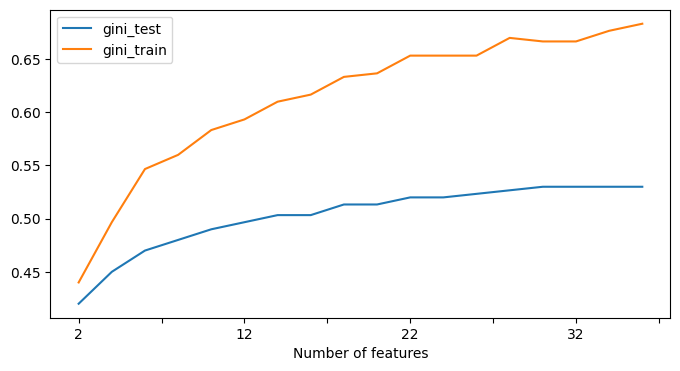

In [49]:
# Forward selection, Будем включать в обучение выборки по одной переменной из списка и оценивать качество модели на кроссвалидации

f = get_features_short_list(
    df=train,
    best_features_df=features_shap,
    num_features_step=2,
    target=target
)

f.plot(x='Number of features', y=['gini_test', 'gini_train'], figsize=(8, 4))

In [50]:
f

,Number of features,gini_test,gini_train,difference
0,2,0.42,0.44,0.02
1,4,0.45,0.496667,0.046667
2,6,0.47,0.546667,0.076667
3,8,0.48,0.56,0.08
4,10,0.49,0.583333,0.093333
5,12,0.496667,0.593333,0.096667
6,14,0.503333,0.61,0.106667
7,16,0.503333,0.616667,0.113333
8,18,0.513333,0.633333,0.12
9,20,0.513333,0.636667,0.123333


**Рисунок 1. Результаты Forward Selection.**

График зависимости Gini от числа включённых признаков. Прирост качества замедляется после включения ~20 переменных, после чего наблюдается расхождение между train и test Gini — признак переобучения. Оптимальное число признаков зафиксировано на уровне 22.


In [51]:
top_n_features = 22

In [52]:
best_features = pd.merge(features_shap.head(top_n_features),
         features_gini[features_gini['Name'].isin(features_shap.head(top_n_features)['Name'])],
         on='Name'
        ).rename(columns={'Value_x': 'SHAP', 'Value_y': 'Gini'}
        ).sort_values(by='Gini', ascending=False)

In [53]:
best_features

,Name,SHAP,Gini
0,EXT_SOURCE_2,0.340035,0.322
1,EXT_SOURCE_3,0.336259,0.317
2,EXT_SOURCE_1,0.178543,0.193
4,AGE_YEARS,0.122199,0.179
6,EMPLOYMENT_RATIO,0.111230,0.176
12,AMT_CREDIT,0.080273,0.142
20,DAYS_ID_PUBLISH,0.052238,0.138
14,OCCUPATION_TYPE,0.073317,0.132
19,AMT_CREDIT_SUM_DEBT_SUM,0.052403,0.129
15,NAME_INCOME_TYPE,0.065286,0.127


In [54]:
selected_cols = features_shap.head(top_n_features)['Name']

In [55]:
len(selected_cols)

22

---

## 7. Обучение базовой модели CatBoost

Обучение модели `CatBoostClassifier` на 22 отобранных признаках с базовыми гиперпараметрами. Метрика качества — нормализованный Gini-коэффициент.


In [56]:
cat_features = train[selected_cols].select_dtypes(['category', 'object']).columns.to_list()

params = {
    'iterations': 100,
    'random_seed': RANDOM_SEED,
    'verbose': 0,
    'eval_metric': 'NormalizedGini',
    'task_type': 'CPU',
    'depth': 2,
    'cat_features': cat_features
 }

In [57]:
def get_gini_clf(model, X: pd.DataFrame, y: pd.Series) -> float:
    """Скоринг и расчет Gini"""
    return round((roc_auc_score(y, model.predict_proba(X)[:, 1]) * 2 - 1) * 100, 2)

In [58]:
def get_gini_by_segments(cols: list[str], model, target,
                         train: pd.DataFrame, test:pd.DataFrame, oot: pd.DataFrame) -> pd.DataFrame:
    """Функция для оценки качества модели на различных сегментах по продуктам"""
    res = []
    for sample, name in [(train, 'Train'), (test, 'Test'), (oot, 'OOT')]:
        print(f'Наблюдений на выборке {name}: {len(sample[cols])}')
        if (len(sample[cols]) > 0) and (sample[target].nunique() > 1):
            res.append({'Выборка': f'{name}',
                        'Gini': get_gini_clf(model, sample[cols], sample[target])})

    return pd.DataFrame(res)

In [59]:
def plot_results(res) -> None:
    """Строит график распределения качества на выборках"""
    def f1(x):
        if 'OOT' in x:
            return 'OOT'
        elif 'PROM' in x:
            return 'PROM'
        elif 'Train' in x:
            return 'Train'
        else:
            return 'Test'

    def f2(x):
        if 'PROM_OOT' in x:
            return x[9:]
        elif 'OOT' in x:
            return x[4:]
        elif 'PROM' in x:
            return x[5:]
        elif 'Train' in x:
            return x[6:]
        else:
            return x[5:]

    res['sample_t'] = res['Выборка'].apply(f1)
    res['Выборка'] = res['Выборка'].apply(f2)

    plt.figure(figsize=(20, 10))
    ax = sns.barplot(res, x='Выборка', y='Gini', hue='sample_t')
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.2f',
            label_type='edge',
            padding=5
        )
    plt.title('Распределение значений Gini')
    plt.legend()
    plt.show()

Наблюдений на выборке Train: 184506
Наблюдений на выборке Test: 61502
Наблюдений на выборке OOT: 61503


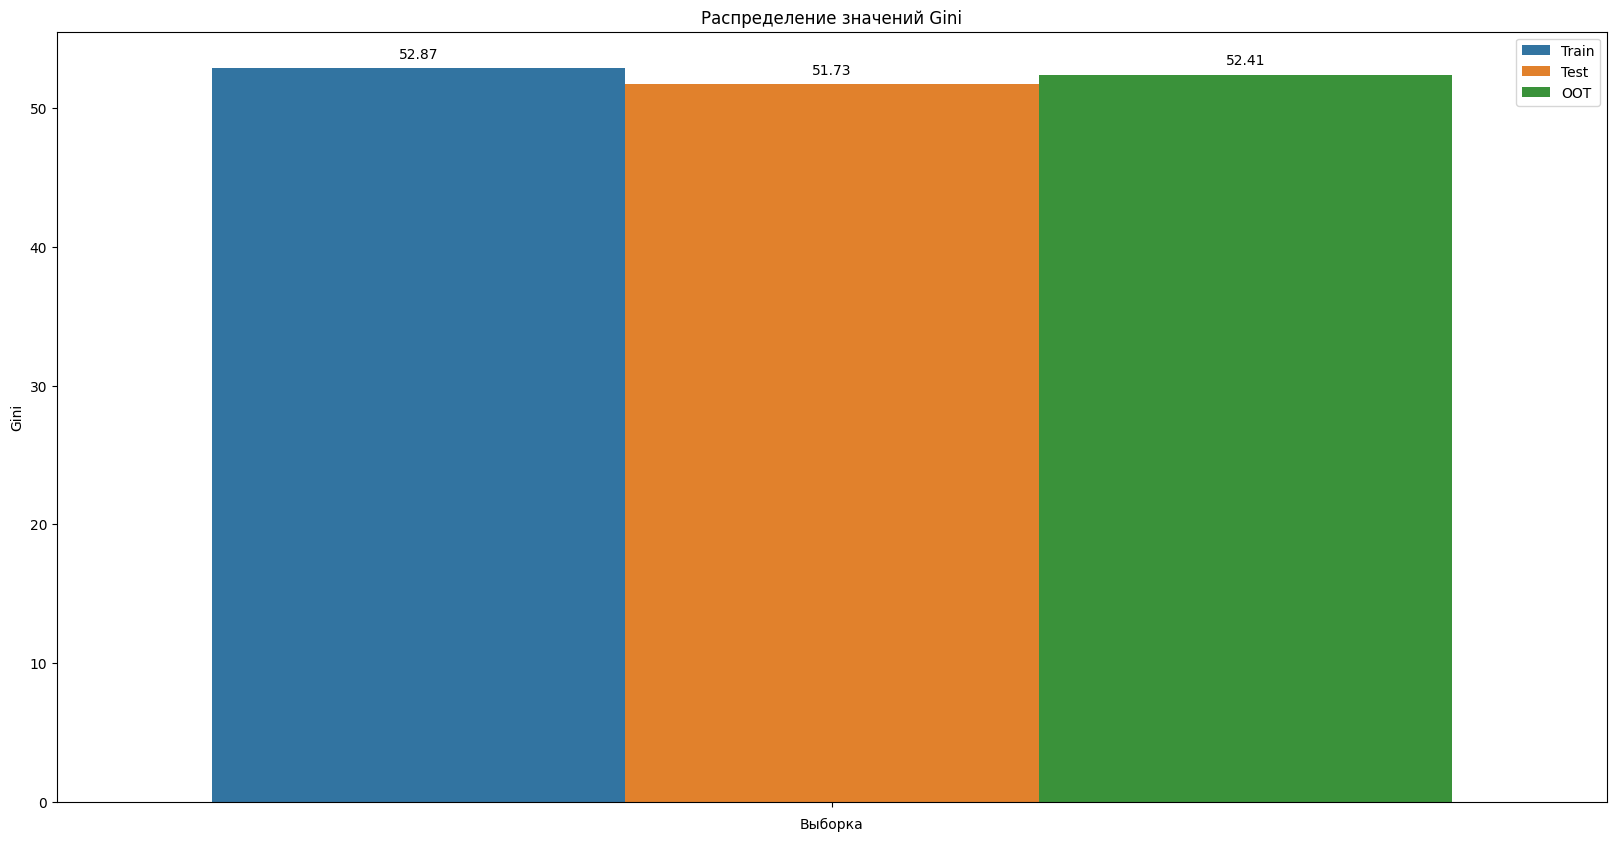

In [60]:
res = []
clf = CatBoostClassifier(**params)
clf.fit(X_train[selected_cols], y_train,
    eval_set=(X_test[selected_cols], y_test))

res = get_gini_by_segments(selected_cols, clf, target,
                          train, test, oot
                          )
plot_results(res)

**Рисунок 2. Качество базовой модели CatBoost по выборкам и сегментам риска.**

Таблица Gini-коэффициентов для обучающей, тестовой и OOT-выборок в разрезе сегментов риска. Базовая модель демонстрирует стабильное качество.


### 7.1 SHAP-анализ базовой модели

SHAP-интерпретация выявляет наиболее значимые признаки и направление их влияния на предсказание. Анализ используется для дополнительной верификации отобранного признакового пространства.


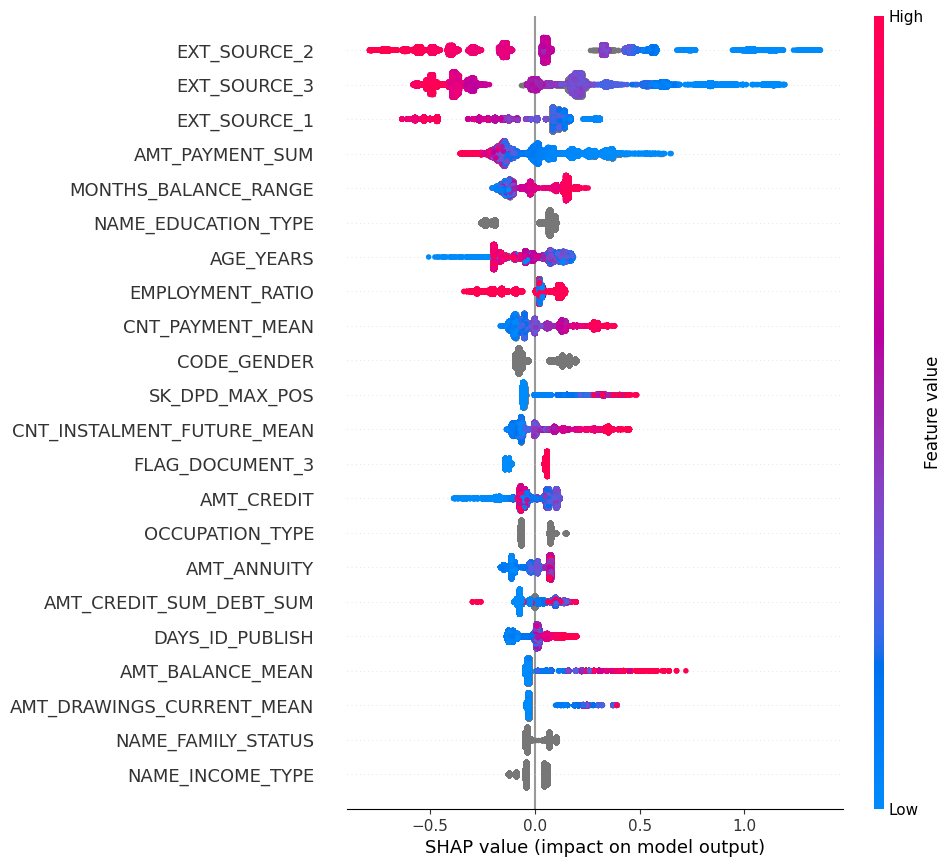

In [61]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test[selected_cols])
shap.plots.beeswarm(shap_values, max_display=len(selected_cols))

**Рисунок 3. SHAP Beeswarm Plot — базовая модель CatBoost.**

Каждая точка соответствует одному наблюдению. Цвет отражает значение признака (красный = высокое, синий = низкое). Признаки ранжированы по среднему абсолютному SHAP-значению. Наибольший вклад вносят внешние скоринговые оценки (`EXT_SOURCE`), кредитная нагрузка и платёжные метрики.


In [62]:
selected_cols.values

array(['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'AMT_PAYMENT_SUM',
       'AGE_YEARS', 'NAME_EDUCATION_TYPE', 'EMPLOYMENT_RATIO',
       'CODE_GENDER', 'AMT_ANNUITY', 'MONTHS_BALANCE_RANGE',
       'CNT_PAYMENT_MEAN', 'CNT_INSTALMENT_FUTURE_MEAN', 'AMT_CREDIT',
       'SK_DPD_MAX_POS', 'OCCUPATION_TYPE', 'NAME_INCOME_TYPE',
       'FLAG_DOCUMENT_3', 'AMT_DRAWINGS_CURRENT_MEAN', 'AMT_BALANCE_MEAN',
       'AMT_CREDIT_SUM_DEBT_SUM', 'DAYS_ID_PUBLISH', 'NAME_FAMILY_STATUS'],
      dtype=object)

In [63]:
features2drop = ['AMT_CREDIT_SUM_DEBT_MEAN']

In [64]:
selected_cols = [col for col in selected_cols if col not in features2drop]

In [65]:
train = train.drop_duplicates(subset=selected_cols).copy()
test = test.drop_duplicates(subset=selected_cols).copy()
oot = oot.drop_duplicates(subset=selected_cols).copy()

In [66]:
X_train = train[selected_cols].copy()
y_train = train[target].copy()

X_test = test[selected_cols].copy()
y_test = test[target].copy()

X_oot = oot[selected_cols].copy()
y_oot = oot[target].copy()

In [67]:
cat_features = train[selected_cols].select_dtypes(['category', 'object']).columns.to_list()

params = {
    'iterations': 100,
    'random_seed': RANDOM_SEED,
    'verbose': 0,
    'eval_metric': 'NormalizedGini',
    'task_type': 'CPU',
    'depth': 2,
    'cat_features': cat_features
 }

Наблюдений на выборке Train: 184506
Наблюдений на выборке Test: 61502
Наблюдений на выборке OOT: 61503


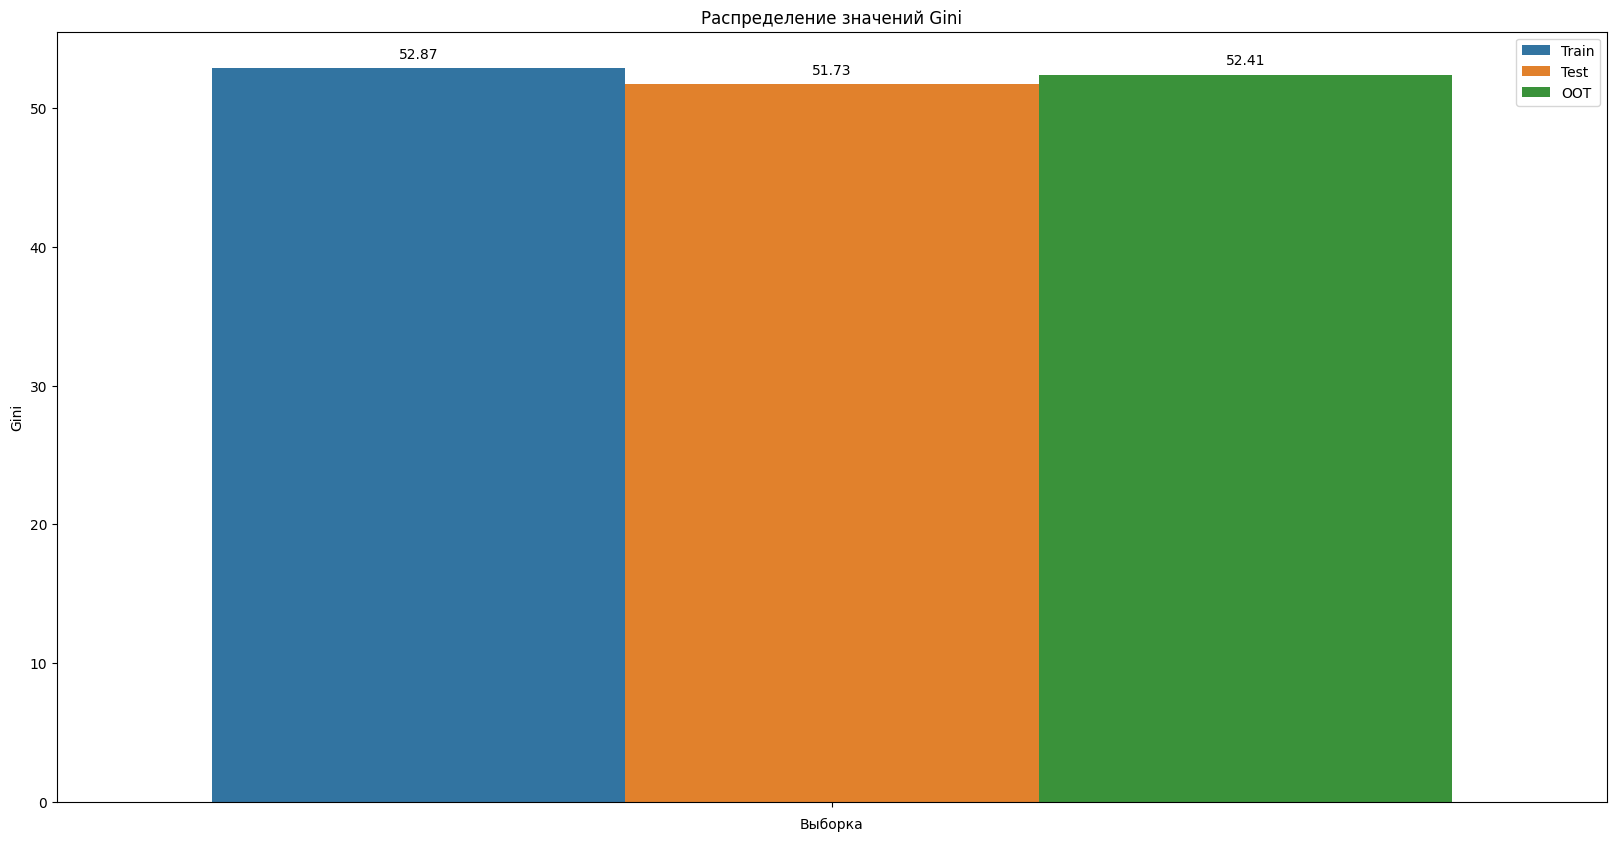

In [68]:
res = []
clf = CatBoostClassifier(**params)
clf.fit(X_train[selected_cols], y_train,
    eval_set=(X_test[selected_cols], y_test))

res = get_gini_by_segments(selected_cols, clf, target,
                          train, test, oot
                          )
plot_results(res)

---

## 8. Подбор гиперпараметров

Оптимизация гиперпараметров модели CatBoost с использованием фреймворка **Optuna** (алгоритм TPE, 50 итераций). Целевая функция — Gini на тестовой выборке. Оптимизируются: `depth`, `learning_rate`, `l2_leaf_reg`, `bagging_temperature`.


In [69]:
cat_features = train[selected_cols].select_dtypes(['category', 'object']).columns.to_list()

In [ ]:
cv = StratifiedKFold(n_splits=5)

def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1, log=True),
        'l2_leaf_reg': trial.suggest_float("l2_leaf_reg", 0, 5.0),
        'early_stopping_rounds': trial.suggest_int("early_stopping_rounds", 1, 1000),
        "subsample": trial.suggest_float("subsample", 0.05, 0.8),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100),
        "depth": trial.suggest_int("depth", 2, 8),
        'random_seed': RANDOM_SEED,
        'eval_metric': 'NormalizedGini',
        'task_type': 'CPU',
        'verbose': 0,
        'cat_features': cat_features
    }

    w = []

    for i, (train_index, val_index) in enumerate(cv.split(X_train, y_train)):
        x_train_opt, x_valid_opt = X_train[selected_cols].iloc[train_index], X_train[selected_cols].iloc[val_index]
        y_train_opt, y_valid_opt = y_train.iloc[train_index], y_train.iloc[val_index]
        model = CatBoostClassifier(**params).fit(
            x_train_opt, y_train_opt,
            eval_set=(x_valid_opt, y_valid_opt)
        )
        w.append([
            roc_auc_score(y_train_opt, model.predict_proba(x_train_opt)[:, 1]),
            roc_auc_score(y_valid_opt, model.predict_proba(x_valid_opt)[:, 1])
        ])
    res = np.mean(w, axis=0)
    test_gini_cv = (2 * res[1] - 1) * 100
    dist =  abs((2 * abs(res[0]) - 1) * 100 - test_gini_cv)
    return round(test_gini_cv - dist, 2)

In [71]:
sampler = TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50)

[I 2026-04-18 13:17:47,247] A new study created in memory with name: no-name-1166d49d-e2e4-437f-b54d-7c76d839c88b
[I 2026-04-18 13:19:35,936] Trial 0 finished with value: 45.65 and parameters: {'iterations': 281, 'learning_rate': 0.002070531614171355, 'l2_leaf_reg': 1.4824984435053605, 'early_stopping_rounds': 94, 'subsample': 0.2998091093732626, 'min_data_in_leaf': 73, 'depth': 6}. Best is trial 0 with value: 45.65.
[I 2026-04-18 13:22:57,410] Trial 1 finished with value: 48.48 and parameters: {'iterations': 554, 'learning_rate': 0.6156342063200575, 'l2_leaf_reg': 3.1370078919304363, 'early_stopping_rounds': 993, 'subsample': 0.1070909332117312, 'min_data_in_leaf': 35, 'depth': 4}. Best is trial 1 with value: 48.48.
[I 2026-04-18 13:24:46,737] Trial 2 finished with value: 49.4 and parameters: {'iterations': 739, 'learning_rate': 0.46694977826492806, 'l2_leaf_reg': 0.40453350240895414, 'early_stopping_rounds': 63, 'subsample': 0.48662622536615624, 'min_data_in_leaf': 67, 'depth': 2}. B

In [72]:
best_params = study.best_params
best_params['verbose'] = 0
best_params['random_seed'] = RANDOM_SEED
best_params['eval_metric'] = 'NormalizedGini'
best_params['task_type'] = 'CPU'
best_params['cat_features'] = []
best_params['cat_features'] = cat_features

In [73]:
for k, v in best_params.items():
    print(f"{k} : {v}")

iterations : 556
learning_rate : 0.04303919588028416
l2_leaf_reg : 3.7040761690245683
early_stopping_rounds : 705
subsample : 0.4015006018546805
min_data_in_leaf : 71
depth : 3
verbose : 0
random_seed : 91
eval_metric : NormalizedGini
task_type : CPU
cat_features : ['NAME_EDUCATION_TYPE', 'CODE_GENDER', 'OCCUPATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS']


---

## 9. Обучение финальной модели

Обучим модель на финальном наборе переменных, с подобранными на прошлом этапе значениями гиперпараметров. Оценим качество модели на выборках и кроссвалидации.

Наблюдений на выборке Train: 184506
Наблюдений на выборке Test: 61502
Наблюдений на выборке OOT: 61503


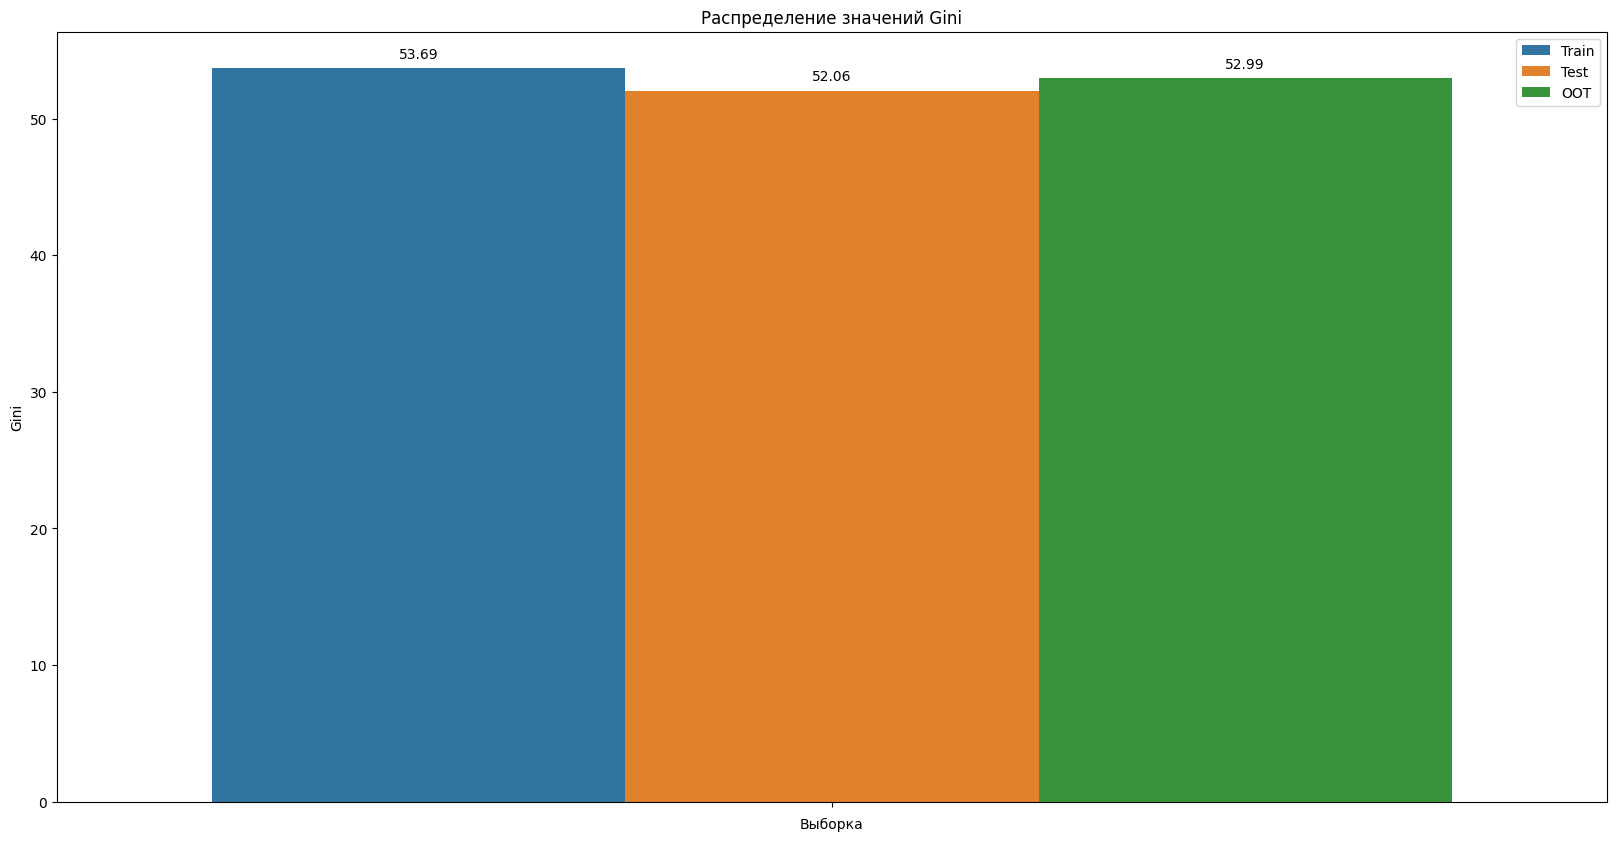

In [74]:
res = []
clf = CatBoostClassifier(**best_params)
clf.fit(X_train[selected_cols], y_train,
    eval_set=(X_test[selected_cols], y_test))

res = get_gini_by_segments(selected_cols, clf, target,
                          train, test, oot
                          )
plot_results(res)

In [75]:
def get_gini(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Расчет Gini"""
    return round((roc_auc_score(y_true, y_pred) * 2 - 1) * 100, 2)

In [76]:
def my_tqdm_cv(X, y, cv, verb=0, trees=500):
    """Реализация кроссвалидации. Используется tqdm для вывода информации об итерациях"""
    score = []
    for i, (train_index, test_index) in enumerate(tqdm(cv.split(X, y), total=cv.get_n_splits(), desc='CV')):

        features = X.columns.to_list()

        # Обучим модель
        cat_features = X.select_dtypes(['category', 'object']).columns.to_list()

        model = CatBoostClassifier(n_estimators=trees,
                                   eval_metric='NormalizedGini',
                                   cat_features = cat_features,                                   verbose=verb,
                                   random_state=RANDOM_SEED)

        model.fit(X.iloc[train_index], y.iloc[train_index])

        gini_train = get_gini(y.iloc[train_index], model.predict_proba(X.iloc[train_index])[:, 1])
        gini_test = get_gini(y.iloc[test_index], model.predict_proba(X.iloc[test_index])[:, 1])

        # Сохраним показатели Джини для каждого фолда
        score.append({
            "train": gini_train,
            "test": gini_test,
         })

        tqdm.write(f'Fold {i+1}, gini_train: {gini_train:.2f}, gini_test: {gini_test:.2f}, train_size: {len(X.iloc[train_index])},\
                       test_size: {len(X.iloc[test_index])}, br_train: {y.iloc[train_index].mean():.2f}, br_test: {y.iloc[test_index].mean():.2f}')
    return pd.DataFrame(score).mean()

In [77]:
tscv = TimeSeriesSplit()

ans = my_tqdm_cv(train[selected_cols], y_train, tscv)
print(f"mean_train_cv_score: {ans['train']}, mean_test_cv_score: {ans['test']}")

CV:  20%|██        | 1/5 [00:44<02:57, 44.50s/it]

Fold 1, gini_train: 79.66, gini_test: 50.26, train_size: 30751,                       test_size: 30751, br_train: 0.08, br_test: 0.08


CV:  40%|████      | 2/5 [01:34<02:22, 47.45s/it]

Fold 2, gini_train: 74.21, gini_test: 51.41, train_size: 61502,                       test_size: 30751, br_train: 0.08, br_test: 0.08


CV:  60%|██████    | 3/5 [02:27<01:40, 50.34s/it]

Fold 3, gini_train: 71.11, gini_test: 49.92, train_size: 92253,                       test_size: 30751, br_train: 0.08, br_test: 0.08


CV:  80%|████████  | 4/5 [03:13<00:48, 48.48s/it]

Fold 4, gini_train: 68.93, gini_test: 52.48, train_size: 123004,                       test_size: 30751, br_train: 0.08, br_test: 0.08


CV: 100%|██████████| 5/5 [04:05<00:00, 49.11s/it]

Fold 5, gini_train: 67.26, gini_test: 53.53, train_size: 153755,                       test_size: 30751, br_train: 0.08, br_test: 0.08
mean_train_cv_score: 72.23400000000001, mean_test_cv_score: 51.519999999999996


## 10. Сохранение результатов

Сохранение обученной модели в формате `.cbm` и параметров модели в `params.json` в директорию `models/cboost/`. Список отфильтрованных признаков экспортируется в `features/filtred_features.xlsx`.


In [81]:
selected_cols

['EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'EXT_SOURCE_1',
 'AMT_PAYMENT_SUM',
 'AGE_YEARS',
 'NAME_EDUCATION_TYPE',
 'EMPLOYMENT_RATIO',
 'CODE_GENDER',
 'AMT_ANNUITY',
 'MONTHS_BALANCE_RANGE',
 'CNT_PAYMENT_MEAN',
 'CNT_INSTALMENT_FUTURE_MEAN',
 'AMT_CREDIT',
 'SK_DPD_MAX_POS',
 'OCCUPATION_TYPE',
 'NAME_INCOME_TYPE',
 'FLAG_DOCUMENT_3',
 'AMT_DRAWINGS_CURRENT_MEAN',
 'AMT_BALANCE_MEAN',
 'AMT_CREDIT_SUM_DEBT_SUM',
 'DAYS_ID_PUBLISH',
 'NAME_FAMILY_STATUS']

In [78]:
clf.save_model(os.path.join(MODELS_PATH, "cboost.cbm"))

In [79]:
with open(os.path.join(MODELS_PATH, "params.json"), "w") as f:
  json.dump(clf.get_all_params(), f)

---

## 13. Qini-кривая и AUUC

**Qini-кривая** — стандартная метрика оценки uplift-моделей. По оси X откладывается доля клиентов, охваченных воздействием (в порядке убывания скора модели); по оси Y — накопленный uplift: разность между долей "исходов" в группе воздействия и группе контроля среди охваченных клиентов.

**AUUC** (Area Under Uplift Curve) — площадь между Qini-кривой модели и базовой линией случайного ранжирования. Более высокий AUUC означает, что модель лучше выявляет клиентов, которые действительно реагируют на воздействие.

Для классических моделей (CatBoost/LogReg) в роли uplift-скора используется предсказанная вероятность дефолта P(default): предполагается, что более рисковые клиенты больше выигрывают от контакта. Для сравнения показана **идеальная модель** (оракул), ранжирующая по TRUE_UPLIFT — теоретический верхний предел AUUC.

In [ ]:
def compute_qini(y_true, treatment, score, n_bins=100):
    """
    Вычисляет Qini-кривую и AUUC (Area Under Uplift Curve).

    Parameters
    ----------
    y_true    : бинарный исход (0/1)
    treatment : бинарный индикатор воздействия (1 = treated, 0 = control)
    score     : скор модели (выше → клиент приоритетнее для контакта)
    n_bins    : число точек на кривой

    Returns
    -------
    fracs     : доля охваченных клиентов (0..1)
    qini_vals : накопленный uplift по модели
    rand_line : базовая линия случайной модели
    auuc      : AUUC — площадь между кривой модели и random baseline
    """
    df_q = pd.DataFrame({
        "y":     np.asarray(y_true,    dtype=float),
        "treat": np.asarray(treatment, dtype=float),
        "score": np.asarray(score,     dtype=float),
    }).sort_values("score", ascending=False).reset_index(drop=True)

    n   = len(df_q)
    n_t = df_q["treat"].sum()
    n_c = n - n_t

    if n_t == 0 or n_c == 0:
        return None, None, None, None

    steps = np.linspace(0, n, n_bins + 1, dtype=int)[1:]
    fracs, qini_vals = steps / n, []

    for k in steps:
        top  = df_q.iloc[:k]
        nt_k = top["treat"].sum()
        nc_k = k - nt_k
        if nt_k == 0 or nc_k == 0:
            qini_vals.append(np.nan)
        else:
            q = (top[top["treat"] == 1]["y"].sum() / n_t
                 - top[top["treat"] == 0]["y"].sum() / n_c)
            qini_vals.append(q)

    qini_vals = np.array(qini_vals, dtype=float)
    full_q    = (df_q[df_q["treat"] == 1]["y"].sum() / n_t
                 - df_q[df_q["treat"] == 0]["y"].sum() / n_c)
    rand_line = fracs * full_q

    valid = ~np.isnan(qini_vals)
    auuc  = np.trapz(qini_vals[valid] - rand_line[valid], fracs[valid])
    return fracs, qini_vals, rand_line, auuc


In [ ]:
# Treatment indicator (1 = contacted, 0 = control)
treatment_test = (test["COMMUNICATION"] != "control").astype(int).values
treatment_oot  = (oot["COMMUNICATION"]  != "control").astype(int).values

# Скор модели: P(default) используется как surrogate-ранжировщик
# (предположение: более рисковые клиенты больше выигрывают от воздействия)
score_test = clf.predict_proba(X_test)[:, 1]
score_oot  = clf.predict_proba(X_oot)[:, 1]

# Идеальная модель — ранжирование по TRUE_UPLIFT (оракул)
# TRUE_UPLIFT < 0 означает снижение PD → выгодное воздействие → сортируем по возрастанию
ideal_score_test = -test["TRUE_UPLIFT"].values
ideal_score_oot  = -oot["TRUE_UPLIFT"].values

# Вычисляем Qini
fracs_t, qini_t, rand_t, auuc_t = compute_qini(y_test, treatment_test, score_test)
fracs_o, qini_o, rand_o, auuc_o = compute_qini(y_oot,  treatment_oot,  score_oot)
fracs_i, qini_i, rand_i, auuc_i = compute_qini(y_test, treatment_test, ideal_score_test)

print(f"AUUC (test):               {auuc_t:.6f}")
print(f"AUUC (oot):                {auuc_o:.6f}")
print(f"AUUC (ideal / oracle):     {auuc_i:.6f}  ← верхняя граница (TRUE_UPLIFT известен)")
print(f"Relative efficiency (test): {auuc_t / auuc_i * 100:.1f}% от идеального")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (fracs, qini_vals, rand_line, fracs_ideal, qini_ideal, label, auuc) in zip(axes, [
    (fracs_t, qini_t, rand_t, fracs_i, qini_i, "Test", auuc_t),
    (fracs_o, qini_o, rand_o, fracs_i, qini_i, "OOT",  auuc_o),
]):
    ax.plot(fracs,       qini_vals,  label=f"CatBoost (AUUC={auuc:.5f})", color="steelblue", lw=2)
    ax.plot(fracs_ideal, qini_ideal, label="Идеальная модель (oracle)",   color="green",     lw=1.5, linestyle="--")
    ax.plot(fracs,       rand_line,  label="Случайная модель",            color="gray",      lw=1.5, linestyle=":")
    ax.fill_between(fracs, qini_vals, rand_line, alpha=0.12, color="steelblue")
    ax.set_title(f"Qini-кривая ({label})")
    ax.set_xlabel("Доля охваченных клиентов")
    ax.set_ylabel("Накопленный uplift")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Qini-кривые CatBoost: модель vs случайное ранжирование vs оракул", fontsize=12)
plt.tight_layout()
plt.show()
